# Frame Extraction from MOV Files

In [2]:
import cv2
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets

In [3]:
VIDEO_DIR = Path("data")
OUTPUT_DIR = Path("data/frames")
IMG_EXT = ".jpg"
JPEG_QUALITY = 95

mov_files = sorted(VIDEO_DIR.glob("*.MOV")) + sorted(VIDEO_DIR.glob("*.mov"))
print(f"Found {len(mov_files)} video(s):")
for f in mov_files:
    print(f"  {f}")

Found 5 video(s):
  data/IMG_9725.MOV
  data/IMG_9726.MOV
  data/IMG_9727.MOV
  data/IMG_9728.MOV
  data/IMG_9729.MOV


In [4]:
def extract_all_frames(video_path: Path, out_dir: Path) -> int:
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"  {video_path.name}: {total} frames @ {fps:.2f} fps  ({w}x{h})")

    saved = 0
    for idx in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(
            str(out_dir / f"frame_{idx:06d}{IMG_EXT}"),
            frame,
            [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
        )
        saved += 1

    cap.release()
    return saved


for video in mov_files:
    out_dir = OUTPUT_DIR / video.stem
    print(f"Extracting {video.name} -> {out_dir}")
    n = extract_all_frames(video, out_dir)
    print(f"  Saved {n} frames\n")

Extracting IMG_9725.MOV -> data/frames/IMG_9725
  IMG_9725.MOV: 1312 frames @ 30.00 fps  (1080x1920)
  Saved 1312 frames

Extracting IMG_9726.MOV -> data/frames/IMG_9726
  IMG_9726.MOV: 283 frames @ 29.97 fps  (1080x1920)
  Saved 283 frames

Extracting IMG_9727.MOV -> data/frames/IMG_9727
  IMG_9727.MOV: 514 frames @ 30.00 fps  (1080x1920)
  Saved 514 frames

Extracting IMG_9728.MOV -> data/frames/IMG_9728
  IMG_9728.MOV: 426 frames @ 29.98 fps  (1080x1920)
  Saved 426 frames

Extracting IMG_9729.MOV -> data/frames/IMG_9729
  IMG_9729.MOV: 590 frames @ 29.96 fps  (1080x1920)
  Saved 590 frames



## Manually pick one frame per video

Set the frame numbers below, then run the cell to copy the selected frames into `data/selected/`.

In [ ]:
import shutil
import matplotlib.pyplot as plt

# ---- Set your chosen frame number for each video ----
selected = {
    "IMG_9706": 0,
    "IMG_9707": 0,
}
# -----------------------------------------------------

SELECTED_DIR = Path("data/selected")
SELECTED_DIR.mkdir(parents=True, exist_ok=True)

previews = []
for stem, frame_num in selected.items():
    src = OUTPUT_DIR / stem / f"frame_{frame_num:06d}{IMG_EXT}"
    if not src.exists():
        print(f"[{stem}] frame {frame_num} not found: {src}")
        continue
    dst = SELECTED_DIR / f"{stem}_frame_{frame_num:06d}{IMG_EXT}"
    shutil.copy2(src, dst)
    print(f"[{stem}] frame {frame_num} -> {dst}")
    previews.append(dst)

for p in previews:
    img = cv2.imread(str(p))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 7))
    plt.imshow(img_rgb)
    plt.title(p.name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Background segmentation

In [2]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-1fizd7nu
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-1fizd7nu
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36590 sha256=be04edf3807c024cb922c64e3b19986fcd8d29ca03294c8797a3049a8171f16d
  Stored in directory: /tmp/pip-ephem-wheel-cache-dg1k1n02/wheels/5d/7b/4a/c7fda89f2e27647dd0816f51ea103992b1b6f0f53ad234895c
Successfully built segment_anything


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import SamPredictor, sam_model_registry
sam = sam_model_registry["default"](checkpoint="sam_vit_h_4b8939.pth")
predictor = SamPredictor(sam)

/home/ahc/miniconda3/lib/python3.13/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


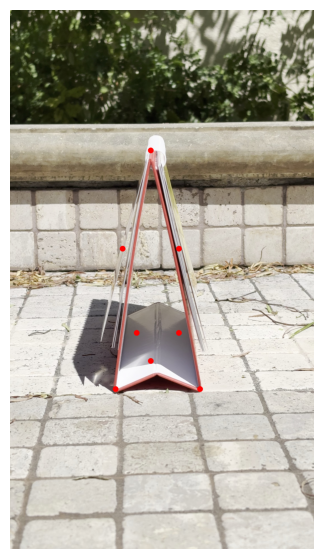

In [43]:
img = cv2.imread("./data/frame_B0.jpg")
points = [(1000, 1000), (1000, 2500), (750, 2700), (1350, 2700), (900, 2300), (1200, 2300), (1200, 1700), (800, 1700)]  # your points here

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for (x, y) in points:
    cv2.circle(img, (x, y), radius=10, color=(255, 0, 0), thickness=20)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

In [45]:
predictor.set_image(img)
masks, _, _ = predictor.predict(point_coords=np.array(points), point_labels=[1] * len(points))  # Nx2 point array

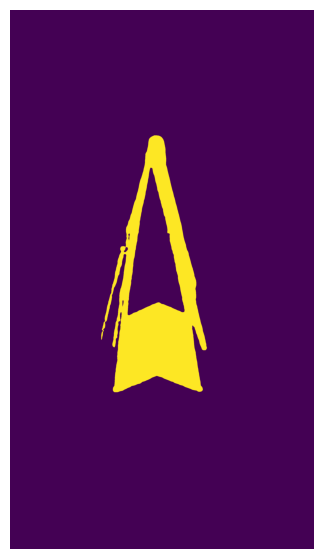

In [64]:
plt.figure(figsize=(10, 7))
plt.imshow(masks[2].astype(np.uint8) * 255)
plt.axis("off")
plt.show()

In [65]:
cv2.imwrite("./data/mask_B0.png", masks[2].astype(np.uint8) * 255)

True

In [9]:
# !pip install rembg
!pip install "numpy<2.0" --force-reinstall


from rembg import remove

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 13.9 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-1.26.4-cp313-cp313-linux_x86_64.whl size=7039554 sha256=466a1f18e6ae96a55d716cfa74d23c8a109f4dbe7e2d8aac29194f01ea009b71
  Stored in directory: /tmp/pip-ephem-wheel-cache-p24mi2yc/wheels/8b/2d/9f/b6b46373f328e2ef50388915d351ccacbedac929459b5459bf
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.8

AttributeError: module 'numpy' has no attribute '_no_nep50_warning'